# X-Ray Dosage Estimates At 60 keV

### Graham Malone

#### February 19th, 2025

### Disclaimer: All of the code used in this document so far was developed by Aiden Boyer.

### Background Information/Notes

The RaEDM experiment requires an electric field ($E$-field) with a magnitude and sign that can be changed quickly during the course of a measurement. The $E$-field is produced between a pair of metal electrodes separated by a gap of a few $mm$ located inside of an ultrahigh vacuum system. A computer-controlled high voltage (HV) system is used to control & monitor the voltage & current supplied to the electrodes. The HV system is composed of a single HV supply and associated control & monitoring circuitry. The purpose of the test station is to condition the electrodes in order to achieve the highest possible electric field while minimizing discharges and leakage currents. Towards this end, we are testing electrodes fabricated
from different materials (copper, niobium, and titanium) as well as studying the effect of adjusting the gap between the electrodes ($0.5 mm$ to $2.5 mm$). The main hazards associated with this equipment are electrical, high pressure & vacuum, and radiological. I'll be focusing on the radiological portion with this code.

The new $60\,kV$ HV power supply for the RaEDM experiment is the **Heinzinger PNChp 60000-1**. When in use, the power supply may produce X-rays due to an electrical discharge between two components at different electric potentials. Discharges in air are not expected to produce X-rays because electrons are not accelerated to high enough energies when they collide with air molecules. However, X-rays could be produced when electrons strike one of the metal electrodes while under vaccum. The X-ray spectrum produced has discrete portions (characteristic X-rays) and a continuous (bremsstrahlung) portion.

[Here is the website that gives the data on the power supply](https://www.heinzinger.com/de/produkte/hochspannungskabel)

### Part 1: Kramer's Formula

The high energy part of bremsstrahlung portion poses a potential hazard here and this high energy part of the spectrum can be approximated using Kramer's Formula:

## $\frac{d^2 N_{\gamma}}{dtdu}=\left[ \frac{I_0}{e} \right] \left[ \frac{2\alpha}{3\sqrt{3\ell}} \right] \left[ \frac{eV_0}{m_e c^2} \right] \left[ \frac{2Z(1-u)}{u} \right]$

Below is a list of the parameters involved in this formula with their definitions:

* $N_\gamma$: The maximum number of X-rays with energy $E$ produced
* $E$: The energy of the X-rays
* $u$: The relative energy of the X-rays, given by $u = \frac{E}{E_0}$
* $E_0$: $E_0 = eV_0$
* $V_0$: The electric potential between the HV electrodes
* $e$: Elementary charge
* $I_0$: Electron beam current
* $\alpha$: Fine structure constant, $\alpha \approx \frac{1}{137}$
* $\ell$: Thickness of the electrode
* $m_e$: Mass of the electron
* $c$: The speed of light, 299,792,458 m/s
* $Z$: Atomic number of the target

### Assumption 1: Angular Distribution Of X-rays Is Isotropic  
  
For X-Ray energies much less than 511 keV (mass of the electron), we can safely assume the angular distribution of the X-rays is isotropic or nearly isotropic (which means that if we were to measure the intensity of the X-rays from any direction, it should be the same for every measurement). With that assumption in mind, the power spectrum can be given by:

## $\frac{dP_b}{du} = \frac{d^2N_{\gamma}}{dtdu}E = P_b\left[2Z(1-u)\right]$

Where $P_b$ is the total unattenuated brehmsstrahlung power, given by the formula below:

## $P_b = \int_{0}^{1} \frac{dP_b}{du}du =\left[ \frac{2\alpha}{3\sqrt{3}\ell} \right] \left[ \frac{eV_0}{m_e c^2} \right] ZP_0$ 

and $P_0 = I_0 V_0$ is the electron beam power

### Assumption 2: Max X-ray Power  
  
We can also assume that the max X-ray power is generated when the HV power supply is operated at the maximum voltage across the Niobium electrodes which is now $60\,kV$ instead of $30\,kV$ ($V_0$ is now $60,000\,V$).

### Assumption 3: Max Electron Beam Current  
  
For the sake of these calculations, we are also going to assume that the max electron beam current $I_0$ is $1\,mA$.

### Assumption 4: Characteristic X-rays  
  
We also assume that the Characteristic X-rays (which are X-rays that are emitted when outer-shell electrons fill a vacancy in the inner shell of an atom due to the atom being ionized and releasing X-rays in a pattern that is "characteristic" to each element) are all emitted at the K-edge (which is a sudden increase in X-ray absorption that occurrs when the energy of the X-rays is just above the binding energy of the innermost electron shell of the atoms interacting with the photons) energy with an intensity that is a factor of 10 greater than the total unattenuated brehmsstrahlung power ($P_c = 10P_b$ at $E_K$)

### Assumption 5: X-ray Penetration  
  
Lastly, we're going to assume that in order to reach any personnel outside the vacuum chamber, the X-rays have to first penetrate pyrex glass which has an equivalent thickness of $5\,mm$. The attenuation length (the distance radiation can travel inside a material before its intensity is reduced significantly) of pyrex glass also varies dramatically with X-ray energy.

### Part 2: X-ray power spectrum at the surface of the Pyrex glass

At the outer surface of the glass, the power spectrum is given by:

## $\frac{dP_a}{du}=\left[ \frac{dP_b}{du}+P_c\delta(u-u_K) \right] e^{-\frac{\Delta t}{t_0(E)}}$

Below is a list of the parameters involved in this formula with their definitions:
* $P_a$: The attenuated X-ray power per unit relative energy
* $\delta(x)$: Dirac delta function (the defining feature of a DDF is that it's $0$ everywhere except at $u = u_K$)
* $u_K$: $u_K = \frac{E_K}{eV_0}$ is the K-edge X-ray energy relative to the voltage between the HV electrodes
* $\Delta t$: The minimum thickness of the pyrex glass ($5\,mm$)
* $t_0(E)$: Attenuation length for an X-ray of energy $E$

We can utilize the algebraic expression for $\frac{dP_b}{du}$, but will still need to implement an integral to obtain the attenuated spectrum. The integration will be performed over u, which can range from 0 to 1.  
  
This is the algebraic expression I'm referring to: substitue $P_b\left[2Z(1-u)\right]$ for $\frac{dP_b}{du}$ and then performing the integral $P_b = \int_{0}^{1} \frac{dP_b}{du}du$ over the interval $0$ to $1$.

### Estimating the Absorbed Dose

To estimate the upper limit on the abosrbed dose we can use the following formula :

## $estimated\, dose \leq \left< P \right> \left[ \left( \frac{I_{dis}}{I_{max}} \right)t_d \right] \left[ \frac{\Omega}{4\pi} \right] \left[ \frac{f_T}{m_T} \right] \left[ \omega_R \omega_T \right] $

Where the parameters have the following definitions:
* $\left<P\right> = \int_{0}^{1} (\frac{dP_a}{du})du$ is the average X-ray power
* $\frac{I_{dis}}{I_0}$: the discharge current relative to the maximum current
* $t_d$: the average duration of the discharge
* $\Omega$: The solid angle covered by the personnel
* $f_T$: fraction of X-rays absorbed by tissue
* $m_T$: mass of tissue
* $\omega_R$: Radiation weighting factor
* $\omega_T$: Tissue weighting factor

### More assumptions based on information from previous electrode conditioning

Experience with previous electrode conditioning implies that:
* $t_d \leq 1$; discharges only occur during electrode conditioning and occur for less than $1$ second. They do not occur after the electrode has been properly conditioned
* X-rays only exit the vacuum chamber through one of the viewports, limiting $\frac{\Omega}{4\pi} \approx \frac{1}{6}$ 
* X-rays are completely absorbed when incident on a person: $f_T = 1$
* The tissue weighting factor is assumed to be $\omega_T=0.2$, the mass of the tissue is assumed to be $m_T=50$ kg, and that radiation weigthing factor is assumed to be $\omega_R=1.0$.

Like Aiden, I will also attempt to reproduce Prof. Singh's results in the HV document to see if our results are the same/different.  
  
Here are the formulas (I gave them above earlier, but I'm writing them here again for my own understanding) we'll be using to calculate the intensity of the characteristic X-rays for Niobium:  
  
## $P_b = \int_{0}^{1} \frac{dP_b}{du}du =\left[ \frac{2\alpha}{3\sqrt{3}\ell} \right] \left[ \frac{eV_0}{m_e c^2} \right] ZP_0$  
  
## $P_c = 10P_b$ at $E_K = 19,000\,eV\,for\,Niobium$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Some constants we will need to define
V_0 = 30000 # Volts
I_0 = 0.001 # Amps
P_0 = I_0 * V_0 # Watts
alpha = 1/137 # unitless
l = 6 # assuming unitless since unit was not given in HV document
m_e = 0.511 # MeV/c^2
Z = 41 # Atomic number for discharge material (Niobium in this case)
c = 1 # units of c
q_e = 1 # units of e
E_0 = q_e*V_0 # eV

# Note: c is assumed to be 1 so units cancel and e is assumed to be in units of e for the same reason. that leaves us with
# the units of P_0 which are watts which is what we want

In [3]:
# Calculate the characteristic X-ray power, which is 10*P_b
term1 = (2 * alpha) / (3 * np.sqrt(3) * l ) # Unitless
term2 = (E_0) / (m_e * 1E6) # Unitless
P_b = term1 * term2 * Z * P_0  # Watts
P_c = 10 * P_b # Watts

# This correctly reproduces the characteristic X-rays for Niobium @ 30 kV, see HV mitigation doc pg. 10
print("P_c = ", P_c, "W")
print("The intensity of the characteristic X-rays is: ", 1000*P_c, "mW")

P_c =  0.33812848767658454 W
The intensity of the characteristic X-rays is:  338.12848767658454 mW


Some dimensional analysis is required for the next part. Previously, Aiden turned the mass attenuation coefficients of XCOM into linear attenuation coefficients and I will be doing the same using the following formula  
## $\ell = \frac{1}{\sigma\rho}$  
where $\sigma$ is the total attenuation with and without coherent scattering given in $\frac{cm^{2}}{g}$ and $\rho$ is the density of the material we're using given in $\frac{g}{cm^{3}}$ which in our case is pyrex. Looking back I think Aiden also used this formula, but it was not explicitly stated.  
  
Note: When you go to XCOM's website, click on "Mixture", and then enter the relevant formulae and relative weights for each compound. These are given in the HV document.

In [4]:
colnames=["Photon Energy [MeV]","Total Attenuation W/ Coherent Scattering [cm^2/g]","Total Attenuation W/O Coherent Scattering [cm^2/g]"]
df = pd.read_csv("Mass Attenuation Data Updated.txt", names=colnames, sep = " ")

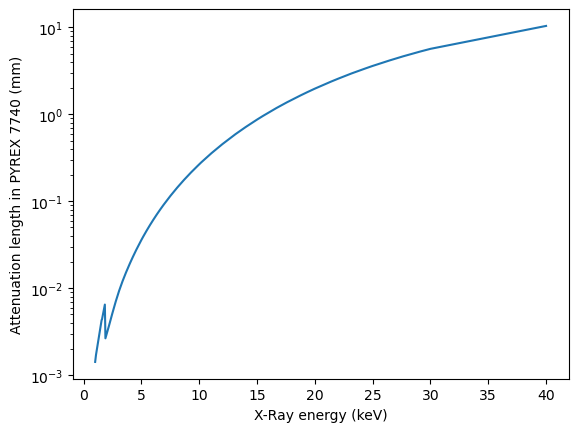

In [5]:
rho = 2.23 # density of Pyrex in g/cm^3
df["Coherent Attenuation Length [mm]"] = 10 / (df["Total Attenuation W/ Coherent Scattering [cm^2/g]"] * rho) # Here we multiply by a factor of 10 to get the linear attenuation coefficients in mm to match the HV document
df["Incoherent Attenuation Length  [mm]"] = 10 / (df["Total Attenuation W/O Coherent Scattering [cm^2/g]"] * rho)
df["Energy [eV]"] = df["Photon Energy [MeV]"] * 1E6

# Plot the attenuation length vs the x-ray energy and see if it matches Figure 4 from the HV Mitigation Doc
plt.plot(df["Energy [eV]"]/1000,df["Coherent Attenuation Length [mm]"]) # Here we multiply by a factor of 1000 to get the energies in keV to match the HV document
plt.xlabel("X-Ray energy (keV)")
plt.ylabel("Attenuation length in PYREX 7740 (mm)")
plt.yscale("log")

In [6]:
# We'll check that the attenuation length of the glass at the characteristic X-ray concentrated at 19 keV is 1.71mm
# Row 73 of the dataframe is where E_K=19 keV is
# We see that the attenuation length matches, suggesting that we're calculating it correctly, and also implying
# That the scattering we are interested in is coherent
df.iloc[82] #index 63 in reg data file

Photon Energy [MeV]                                       0.018760
Total Attenuation W/ Coherent Scattering [cm^2/g]         2.713000
Total Attenuation W/O Coherent Scattering [cm^2/g]        2.547000
Coherent Attenuation Length [mm]                          1.652895
Incoherent Attenuation Length  [mm]                       1.760622
Energy [eV]                                           18760.000000
Name: 82, dtype: float64

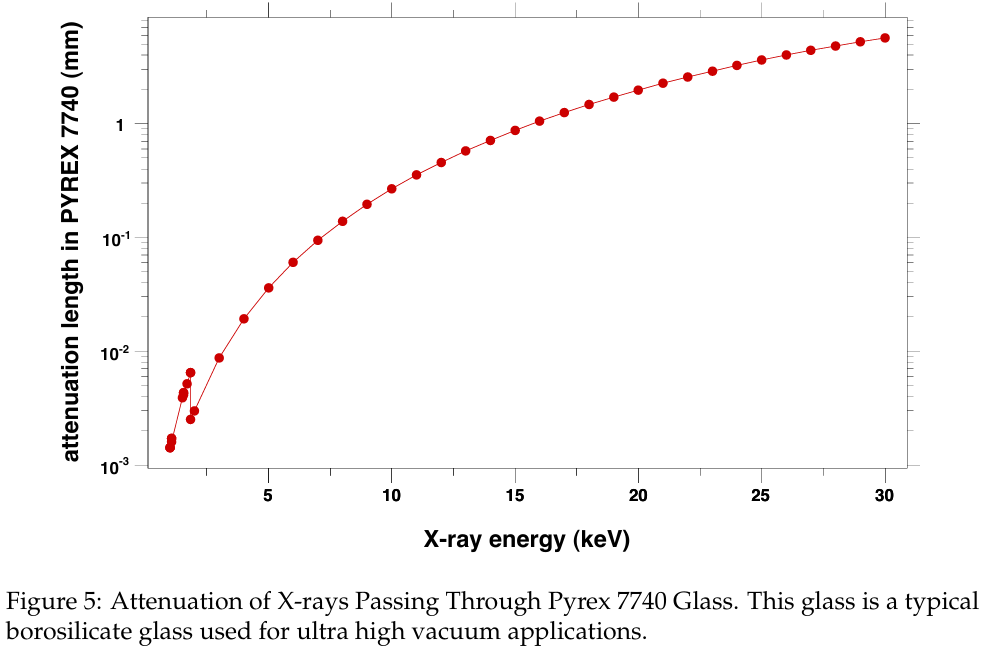

Pictured above is the graph that Prof. Singh generated in the HV document. When I compare his to the one Aiden generated, they match up pretty well, but there is a slight discrepancy.

### $V_0 = 60\,keV$